<a href="https://colab.research.google.com/github/Torreblanca87/Challenge2_Alura_TelecomX/blob/main/TelecomX_LATAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📖 Bibliotecas y librerias

In [66]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import requests
import json
import datetime
import chardet
from scipy.stats import pointbiserialr

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
carpeta_graficos = '/content/drive/MyDrive/Colab Notebooks/Challenge_TelecomX/Graficos'

Mounted at /content/drive


#📌 Extracción

In [4]:
#Enlace web.
enlaceApi = 'https://github.com/alura-cursos/challenge2-data-science-LATAM/blob/main/TelecomX_Data.json'
#Servidor de contenido crudo de GitHub
enlace_raw_data = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json'

In [5]:
# Request para obtener la respuesta de la url.
acceso = requests.get(enlace_raw_data)
json_nativo = json.loads(acceso.text)
df = pd.DataFrame(json_nativo)
df.head(2)

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


#🔧 Transformación

In [6]:
df = pd.json_normalize(json_nativo)
df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [7]:
#Prefijos a eliminar.
prefijos = ['customer.', 'phone.', 'internet.', 'acount.', 'charges.']

#Listas para el mapeo.
nombres_actuales = []
nombres_limpios = []

#Iterar sobre las columnas del DataFrame
for col in df.columns:
    es_prefijo = False

    # Verificar si la columna comienza con alguno de los prefijos.
    for prefijo in prefijos:
        if col.startswith(prefijo):
            nombres_actuales.append(col)
            #Eliminar el prefijo para obtener el nombre limpio
            nombres_limpios.append(col.replace(prefijo, '', 1))
            es_prefijo = True
            break
    # Si la columna no tiene prefijo se mantiene igual.
    if not es_prefijo:
        nombres_actuales.append(col)
        nombres_limpios.append(col)

# Usar Zip() para crear el diccionario de mapeo.
# Empareja (zip) los nombres actuales con los nombres limpios
mapeo_renombre = dict(zip(nombres_actuales, nombres_limpios))

# Renombrados con .rename()
# Le pasamos el diccionario de mapeo generado por zip
df = df.rename(columns=mapeo_renombre)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customerID                7267 non-null   object 
 1   Churn                     7267 non-null   object 
 2   gender                    7267 non-null   object 
 3   SeniorCitizen             7267 non-null   int64  
 4   Partner                   7267 non-null   object 
 5   Dependents                7267 non-null   object 
 6   tenure                    7267 non-null   int64  
 7   PhoneService              7267 non-null   object 
 8   MultipleLines             7267 non-null   object 
 9   InternetService           7267 non-null   object 
 10  OnlineSecurity            7267 non-null   object 
 11  OnlineBackup              7267 non-null   object 
 12  DeviceProtection          7267 non-null   object 
 13  TechSupport               7267 non-null   object 
 14  Streamin

In [8]:
# Visualizamos los nombres de los encabezados en lista.
df.columns.tolist()

['customerID',
 'Churn',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'account.Contract',
 'account.PaperlessBilling',
 'account.PaymentMethod',
 'account.Charges.Monthly',
 'account.Charges.Total']

In [9]:
# Cambiar nombre al Español de las columnas.
columnas_es = [
    'ID_Cliente',
    'Desercion',
    'Genero',
    'Adulto_Mayor',
    'Pareja',
    'Dependientes',
    'Antigüedad_Meses',
    'Servicio_Telefono',
    'Lineas_Multiples',
    'Servicio_Internet',
    'Seguridad_Online',
    'Respaldo_Online',
    'Proteccion_Dispositivo',
    'Soporte_Tecnico',
    'Streaming_TV',
    'Streaming_Peliculas',
    'Tipo_Contrato',
    'Facturacion_Sin_Papel',
    'Metodo_Pago',
    'Cargo_Mensual',
    'Cargo_Total',
]


In [10]:
from scipy._lib.doccer import Mapping
#Modificacion de columnas
mapping = dict(zip(df.columns, columnas_es))
df = df.rename(columns=mapping)
df.head()

,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [11]:
#Identificamos si hay valores vacios.
columnas_con_vacios = [
    col for col in df.columns
    if df[col].astype(str).str.strip().eq('').any()
]
print("Columnas con vacios:", columnas_con_vacios)

Columnas con vacios: ['Desercion', 'Cargo_Total']


In [12]:
# Remplazar '', ' ', '   ', np.nan en todas las columnas string.
df = df.replace(r'^\s*$', np.nan, regex=True)

In [13]:
df['Cargo_Total'] = pd.to_numeric(df['Cargo_Total'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7267 non-null   object 
 1   Desercion               7043 non-null   object 
 2   Genero                  7267 non-null   object 
 3   Adulto_Mayor            7267 non-null   int64  
 4   Pareja                  7267 non-null   object 
 5   Dependientes            7267 non-null   object 
 6   Antigüedad_Meses        7267 non-null   int64  
 7   Servicio_Telefono       7267 non-null   object 
 8   Lineas_Multiples        7267 non-null   object 
 9   Servicio_Internet       7267 non-null   object 
 10  Seguridad_Online        7267 non-null   object 
 11  Respaldo_Online         7267 non-null   object 
 12  Proteccion_Dispositivo  7267 non-null   object 
 13  Soporte_Tecnico         7267 non-null   object 
 14  Streaming_TV            7267 non-null   

In [14]:
# Detectar columnas con valores NaN despues del remplazo.
columnas_nulas = df.columns[df.isnull().any()].tolist()
print("Columnas con nulls:", columnas_nulas)

Columnas con nulls: ['Desercion', 'Cargo_Total']


In [15]:
for col in columnas_nulas:
    nulos = df[col].isnull().sum()
    porcentaje = df[col].isnull().mean() * 100
    print(f"Columna: {col}")
    print(f" - Cantidad de nulos: {nulos:,}")
    print(f" - Porcentaje: {porcentaje:.4f}%\n")

Columna: Desercion
 - Cantidad de nulos: 224
 - Porcentaje: 3.0824%

Columna: Cargo_Total
 - Cantidad de nulos: 11
 - Porcentaje: 0.1514%



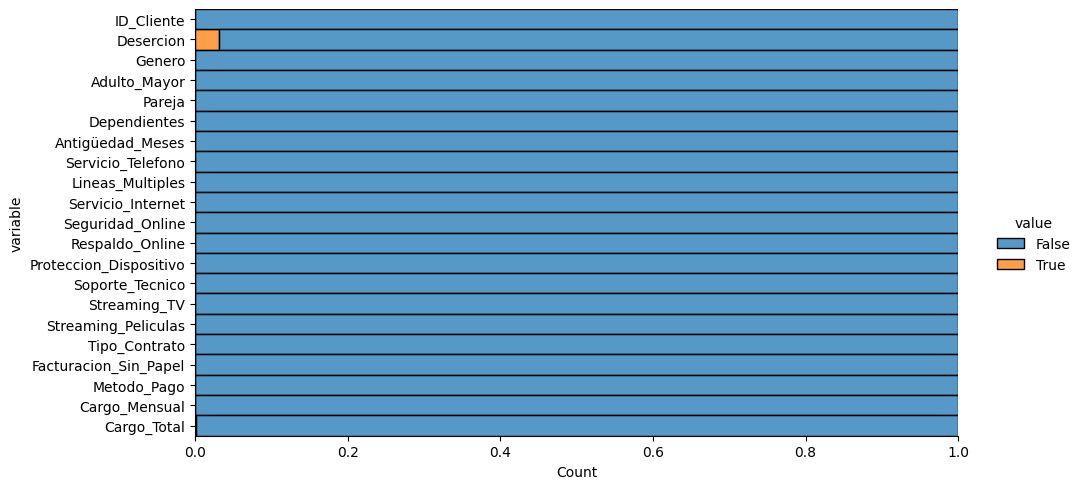

In [16]:
# Grafico que nos permite visualizar datos faltantes.
df_validacion = df.isnull().melt()
sns.displot(data=df_validacion, y='variable', hue='value', multiple='fill', aspect=2)
plt.show()

In [17]:
#Eliminar registros vacios o null
df = df.dropna(subset=['Cargo_Total', 'Desercion'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7032 non-null   object 
 1   Desercion               7032 non-null   object 
 2   Genero                  7032 non-null   object 
 3   Adulto_Mayor            7032 non-null   int64  
 4   Pareja                  7032 non-null   object 
 5   Dependientes            7032 non-null   object 
 6   Antigüedad_Meses        7032 non-null   int64  
 7   Servicio_Telefono       7032 non-null   object 
 8   Lineas_Multiples        7032 non-null   object 
 9   Servicio_Internet       7032 non-null   object 
 10  Seguridad_Online        7032 non-null   object 
 11  Respaldo_Online         7032 non-null   object 
 12  Proteccion_Dispositivo  7032 non-null   object 
 13  Soporte_Tecnico         7032 non-null   object 
 14  Streaming_TV            7032 non-null   objec

In [18]:
df.nunique()

,0
ID_Cliente,7032
Desercion,2
Genero,2
Adulto_Mayor,2
Pareja,2
Dependientes,2
Antigüedad_Meses,72
Servicio_Telefono,2
Lineas_Multiples,3
Servicio_Internet,3


In [19]:
columnas_object = df.select_dtypes(include='object').columns.tolist()
print(columnas_object)

['ID_Cliente', 'Desercion', 'Genero', 'Pareja', 'Dependientes', 'Servicio_Telefono', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Sin_Papel', 'Metodo_Pago']


In [20]:
columnas_object = df.select_dtypes(include='object').columns
print(f"Columnas de tipo 'object' a analizar: {columnas_object.tolist()}\n")

for col in columnas_object:
  print(f"\n Columna: {col} (Valores únicos: {df[col].nunique()})")
  print(df[col].value_counts())

Columnas de tipo 'object' a analizar: ['ID_Cliente', 'Desercion', 'Genero', 'Pareja', 'Dependientes', 'Servicio_Telefono', 'Lineas_Multiples', 'Servicio_Internet', 'Seguridad_Online', 'Respaldo_Online', 'Proteccion_Dispositivo', 'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas', 'Tipo_Contrato', 'Facturacion_Sin_Papel', 'Metodo_Pago']


 Columna: ID_Cliente (Valores únicos: 7032)
ID_Cliente
9995-HOTOH    1
0002-ORFBO    1
0003-MKNFE    1
0004-TLHLJ    1
0011-IGKFF    1
             ..
0018-NYROU    1
0017-IUDMW    1
0017-DINOC    1
0016-QLJIS    1
0015-UOCOJ    1
Name: count, Length: 7032, dtype: int64

 Columna: Desercion (Valores únicos: 2)
Desercion
No     5163
Yes    1869
Name: count, dtype: int64

 Columna: Genero (Valores únicos: 2)
Genero
Male      3549
Female    3483
Name: count, dtype: int64

 Columna: Pareja (Valores únicos: 2)
Pareja
No     3639
Yes    3393
Name: count, dtype: int64

 Columna: Dependientes (Valores únicos: 2)
Dependientes
No     4933
Yes    2099
Name:

In [21]:
cols_texto = ['Metodo_Pago', 'Genero', 'Tipo_Contrato', 'Pareja',
              'Desercion', 'Dependientes', 'Servicio_Telefono', 'Facturacion_Sin_Papel']

# Aplica strip y astype(str) individualmente para evitar posibles problemas de SettingWithCopyWarning
for col_name in cols_texto:
    df[col_name] = df[col_name].astype(str).str.strip()

map_traducciones = {
    'Metodo_Pago': {
        'Electronic check': 'Cheque Electronico',
        'Mailed check': 'Cheque por Correo',
        'Bank transfer (automatic)': 'Transferencia Bancaria',
        'Credit card (automatic)': 'Tarjeta de Credito'
    },
    'Genero': {
        'Female': 'Femenino',
        'Male': 'Masculino'
    },
    'Tipo_Contrato': {
        'Month-to-month': 'Mensual',
        'One year': '1 año',
        'Two year': '2 años'
    }
}

for col, mapa in map_traducciones.items():
    if col == 'Genero': # Depurando específicamente para Genero
        print(f"Depurando '{col}' antes del mapeo:")
        print(f"  Dtype: {df[col].dtype}")
        print(f"  Valores únicos: {df[col].unique()}")
        print(f"  Conteo de valores:\n{df[col].value_counts()}")
    df[col] = df[col].map(mapa)

df.head()

Depurando 'Genero' antes del mapeo:
  Dtype: object
  Valores únicos: ['Female' 'Male']
  Conteo de valores:
Genero
Male      3549
Female    3483
Name: count, dtype: int64


,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,No,Femenino,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,1 año,Yes,Cheque por Correo,65.6,593.30
1,0003-MKNFE,No,Masculino,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Mensual,No,Cheque por Correo,59.9,542.40
2,0004-TLHLJ,Yes,Masculino,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Mensual,Yes,Cheque Electronico,73.9,280.85
3,0011-IGKFF,Yes,Masculino,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Mensual,Yes,Cheque Electronico,98.0,1237.85
4,0013-EXCHZ,Yes,Femenino,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Mensual,Yes,Cheque por Correo,83.9,267.40


In [22]:
map_binario = {'No': 0, 'Si': 1, 'Yes': 1}

cols_binarias = [
    'Pareja', 'Desercion', 'Dependientes',
    'Servicio_Telefono', 'Facturacion_Sin_Papel'
]

df[cols_binarias] = (
  df[cols_binarias]
    .replace(map_binario)
    .infer_objects(copy=False)
    .astype('Int64')
)

df.head(2)

/tmp/ipykernel_236/125546382.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .replace(map_binario)


,ID_Cliente,Desercion,Genero,Adulto_Mayor,Pareja,Dependientes,Antigüedad_Meses,Servicio_Telefono,Lineas_Multiples,Servicio_Internet,...,Respaldo_Online,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Facturacion_Sin_Papel,Metodo_Pago,Cargo_Mensual,Cargo_Total
0,0002-ORFBO,0,Femenino,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,1 año,1,Cheque por Correo,65.6,593.3
1,0003-MKNFE,0,Masculino,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Mensual,0,Cheque por Correo,59.9,542.4


#📊 Carga y análisis

## Analisis General

### Distribucion por Genero

In [23]:
# Distribucion por Genero
frecuencia_genero = df['Genero'].value_counts()
porcentaje = df['Genero'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Total': frecuencia_genero,
    'Porcentaje': porcentaje
})

resumen['Total'] = resumen['Total'].apply(lambda x: f'{x:,.0f}')
resumen['Porcentaje'] = resumen['Porcentaje'].apply(lambda x: f'{x:.2f}%')

resumen


,Total,Porcentaje
Genero,,
Masculino,"3,549",50.47%
Femenino,"3,483",49.53%


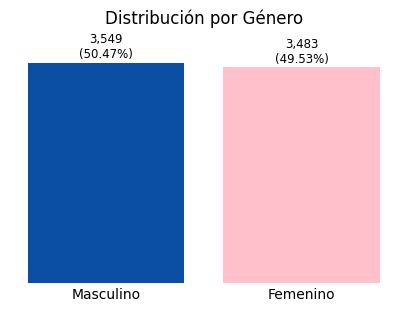

In [24]:
frecuencia_genero = df['Genero'].value_counts()
porcentaje = df['Genero'].value_counts(normalize=True) * 100

colores = ['#0A4FA3', '#FFC0CB']

fig, ax = plt.subplots(figsize=(5, 3))

ax.set_frame_on(False)
ax.tick_params(axis='x', which='both', size = 0)

ax.bar(frecuencia_genero.index, frecuencia_genero.values, color=colores)

ax.set_title('Distribución por Género', pad=20)
ax.set_yticks([])

for i, (total, pct) in enumerate(zip(frecuencia_genero.values, porcentaje.values)):
    ax.text(i, total + 30,
            f'{total:,}\n({pct:.2f}%)',
            color='black',
            fontsize=8.5,
            ha='center', va='bottom')

plt.show()

### Proporcion de clientes segun perfil etario

In [25]:
distribucion_demografico = df['Adulto_Mayor'].value_counts()
porcentajes = df['Adulto_Mayor'].value_counts(normalize=True) * 100

#Construir DataFrame base
resumen = pd.DataFrame({
    'Total': distribucion_demografico,
    'Porcentaje': porcentajes.round(2)
})

#Formatear columnas de salida
resumen['Porcentaje'] = resumen['Porcentaje'].apply(lambda x: f'{x:,.2f} %')
resumen['Total'] = resumen['Total'].apply(lambda x: f'{x:,.0f}')
resumen.index.name = 'Adulto Mayor'

resumen

,Total,Porcentaje
Adulto Mayor,,
0,"5,890",83.76 %
1,"1,142",16.24 %


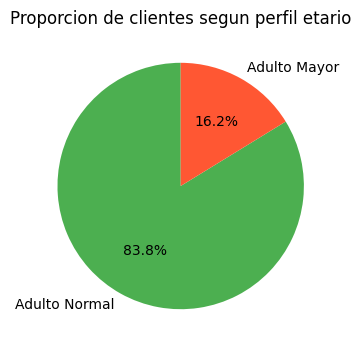

In [26]:
from enum import auto
#Distribucion de perfil
distribucion_demografico = df['Adulto_Mayor'].value_counts()

#Crear etiquetas legibles.
etiquetas = ['Adulto Normal', 'Adulto Mayor']

colores = ['#4CAF50', '#FF5733']

plt.figure(figsize=(4, 4))
plt.pie(
    distribucion_demografico,
    autopct='%1.1f%%',
    labels=etiquetas,
    colors=colores,
    startangle=90,
)

plt.title('Proporcion de clientes segun perfil etario')

plt.show()

### Conclusiones:
-
  Los Adultos Mayores solo representa un total de 16%.

### Distribucion de clientes segun convivencia (vive solo vs en pareja)

In [27]:
distribucion_socio = df['Pareja'].value_counts()
porcentajes = df['Pareja'].value_counts(normalize=True) * 100

#Construir el DataFrame base
resumen = pd.DataFrame({
    'Total': distribucion_socio,
    'Porcentaje': porcentajes.round(2)
})

#Formatear formatos de salida.
resumen['Porcentaje'] = resumen['Porcentaje'].apply(lambda x: f'{x:,.2f} %')
resumen['Total'] = resumen['Total'].apply(lambda x: f'{x:,.0f}')
resumen.index.name = 'Pareja'

resumen

,Total,Porcentaje
Pareja,,
0,"3,639",51.75 %
1,"3,393",48.25 %


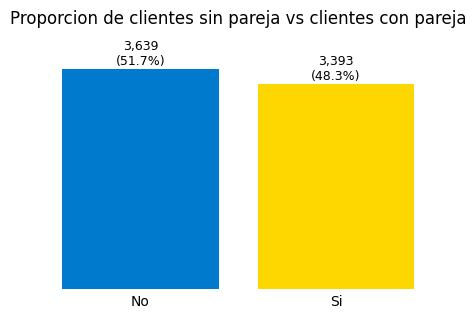

In [28]:
# Conteo
socio = df['Pareja'].value_counts()

#Remplazar etiquetas del indice.
socio.index = socio.index.map({0: 'No', 1: 'Si'})

#Porcentajes alineados con socio.
porcentaje = (socio / socio.sum()) * 100

#Colores. Nueva paleta: Azul más oscuro y un amarillo/dorado
colores = ['#007ACC', '#FFD700']

#Grafico
fig, ax = plt.subplots(figsize=(5, 3))
ax.set_frame_on(False)
ax.tick_params(axis='x', which='both', size=0)

ax.bar(socio.index, socio.values, color=colores)
ax.set_title('Proporcion de clientes sin pareja vs clientes con pareja', pad=25)
ax.set_yticks([])

#Etiquetas
for i, (total, pct) in enumerate(zip(socio.values, porcentaje.values)):
  ax.text(i, total + 30,
          f'{total:,.0f}\n({pct:.1f}%)',
          ha='center',
          va='bottom',
          fontsize=9
    )

plt.show()

### Conclusiones:
- Clientes individuales representa casi el 52% del total de datos y solo el 48% clientes con pareja o asociados.

### Distribucion por Antiüedad.

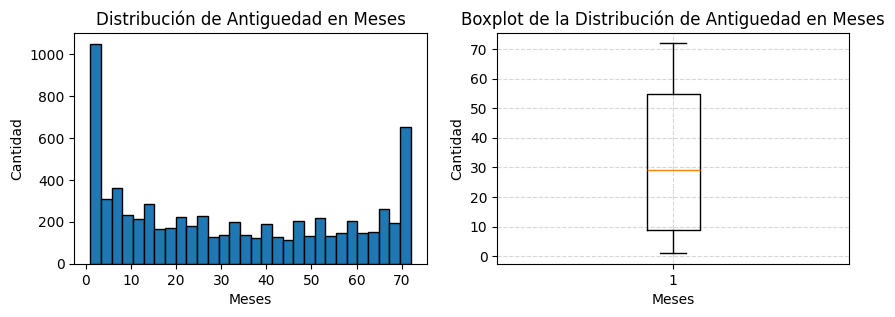

In [29]:
# Crea la Figura y los Ejes. Inicializa un lienzo (fig) y una matriz de Ejes (axs) con 1 fila y 2 columnas. El tamaño de la figura es de 12 con 4 pulgadas.
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].hist(df['Antigüedad_Meses'], bins=30, edgecolor="black")
axs[0].set_title('Distribución de Antiguedad en Meses')
axs[0].set_xlabel('Meses')
axs[0].set_ylabel('Cantidad')

axs[1].boxplot(df['Antigüedad_Meses'])
axs[1].set_title('Boxplot de la Distribución de Antiguedad en Meses')
axs[1].set_xlabel('Meses')
axs[1].set_ylabel('Cantidad')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

#### Conclusiones:
- El histograma nos indica que la antigüedad tiene una distribución bimodal con una forma de U, lo que significa que no es simétrica. La mayoría de las personas se concentran en los extremos: nuevos (Antigüedad ~0) y antiguos (Antigüedad ~70), mientras que el grupo intermedio es el menos numeroso.

- El rango intercuartílico (la caja) es muy amplio, cubriendo una gran parte del rango total de antigüedad (casi todo el rango central de 10 a 55). Esto indica una alta dispersión de los datos.

### Distribucion por Recarga Mensual.

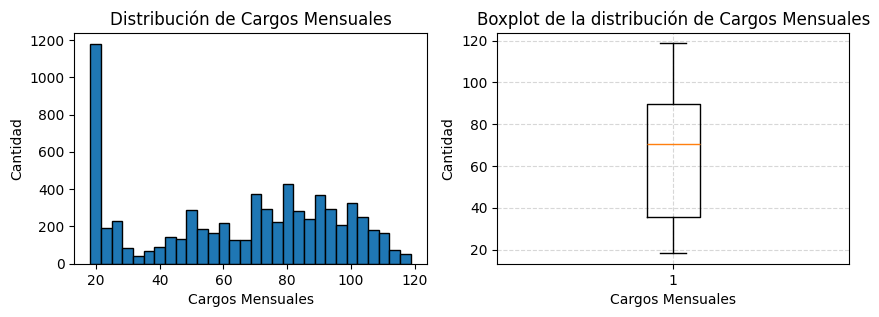

In [30]:
# Crea la Figura y los Ejes. Inicializa un lienzo (fig) y una matriz de Ejes (axs) con 1 fila y 2 columnas. El tamaño de la figura es de 12 con 4 pulgadas.
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].hist(df['Cargo_Mensual'], bins=30, edgecolor="black")
axs[0].set_title('Distribución de Cargos Mensuales')
axs[0].set_xlabel('Cargos Mensuales')
axs[0].set_ylabel('Cantidad')

axs[1].boxplot(df['Cargo_Mensual'])
axs[1].set_title('Boxplot de la distribución de Cargos Mensuales')
axs[1].set_xlabel('Cargos Mensuales')
axs[1].set_ylabel('Cantidad')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

#### Conclusiones:
- La empresa tiene una gran base de clientes que solo consumen el servicio básico (recargas bajas), pero también mantiene una cantidad significativa de clientes con una amplia gama de consumos medios y altos.

- La mediana (70) está mucho más cerca del tercer cuartil (90), lo cual es una señal clara de la asimetría negativa que ya vimos en el histograma.

### Distribución de Recargas Totales.

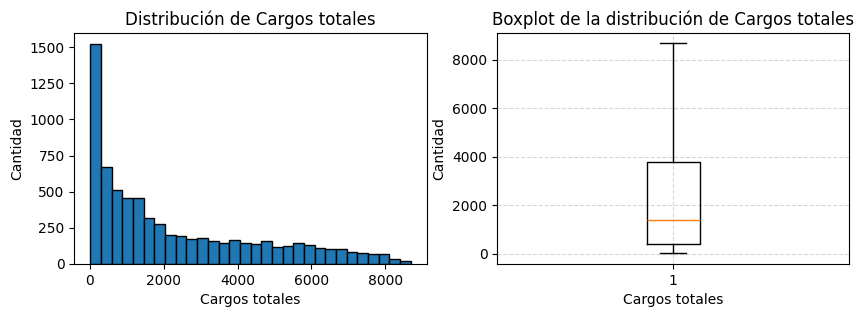

In [31]:
# Crea la Figura y los Ejes. Inicializa un lienzo (fig) y una matriz de Ejes (axs) con 1 fila y 2 columnas. El tamaño de la figura es de 12 con 4 pulgadas.
fig, axs = plt.subplots(1, 2, figsize=(10, 3))

axs[0].hist(df['Cargo_Total'], bins=30, edgecolor="black")
axs[0].set_title('Distribución de Cargos totales')
axs[0].set_xlabel('Cargos totales')
axs[0].set_ylabel('Cantidad')

axs[1].boxplot(df['Cargo_Total'])
axs[1].set_title('Boxplot de la distribución de Cargos totales')
axs[1].set_xlabel('Cargos totales')
axs[1].set_ylabel('Cantidad')
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.show()

## Análisis de Abandono (Churn) Profundizado

### ¿Cómo se distribuye la base de clientes entre desertores y no desertores?

In [32]:
total = df['Desercion'].value_counts()
total_porcentaje = df['Desercion'].value_counts(normalize=True)*100

resultados = pd.DataFrame({
    'Total': total,
    'Porcentaje': total_porcentaje
})

resultados['Total'] = resultados['Total'].apply(lambda x: f'{x:,.0f}')
resultados['Porcentaje'] = resultados['Porcentaje'].apply(lambda x: f'{x:.1f}%')

resultados.index.name = 'Desercion'

resultados

,Total,Porcentaje
Desercion,,
0,"5,163",73.4%
1,"1,869",26.6%


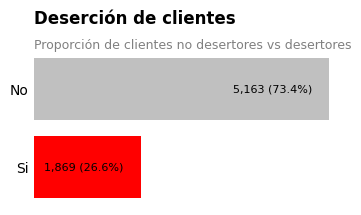

In [33]:
# Dataframe a gráficar
df_churn = (
    df['Desercion']
    .value_counts()
    .rename_axis('Desercion')
    .reset_index(name='Total')
)

df_churn['Desercion'] = df_churn['Desercion'].astype('object')

df_churn['Porcentaje'] = df_churn['Total'] / df_churn['Total'].sum() * 100
df_churn['Desercion'] = df_churn['Desercion'].replace({0: 'No', 1: 'Si'})
df_churn = df_churn.sort_values('Total', ascending=True)

# Colores, resaltamos el Si
colores = []
for desercion in df_churn['Desercion']:
  if desercion == 'Si':
    colores.append('red')
  else:
    colores.append('silver')

#Gráfico
fig, ax = plt.subplots(figsize=(4,2)) # Definimos el tamaño del lienzo

ax.set_frame_on(False)    # Oculta el marco del gráfico
ax.xaxis.set_visible(False)                    # Oculta el eje X completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y

ax.barh(df_churn['Desercion'],df_churn['Total'], color=colores)
ax.set_title('Deserción de clientes', fontsize=12, weight='bold', pad=20, loc='left')
ax.text(
    0.0, 1.02,
    'Proporción de clientes no desertores vs desertores',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)


# Etiquetas en cada barra
for i, (total, pct) in enumerate(zip(df_churn['Total'], df_churn['Porcentaje'])):
    ax.text(
        total - 300,        # X → al final de la barra
        i,                 # Y → posición de la barra
        f'{total:,.0f} ({pct:.1f}%)',
        va='center',
        ha='right',
        fontsize=8,
        color='black'
    )

# Guardar Gráfico como PNG
fig.savefig(carpeta_graficos+'/Distribución_desercion.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

### ¿Los clientes que desertan tienen menor antigüedad que el promedio general?

In [34]:
desertores = df.loc[df['Desercion'] == 1, 'Antigüedad_Meses'].describe()
general = df['Antigüedad_Meses'].describe()

resumen = pd.concat(
    [desertores, general],
    axis=1,
    keys=['Desertores', 'General']
).reset_index().rename(columns={'index': 'Descripción'})


resumen

,Descripción,Desertores,General
0,count,1869.000000,7032.000000
1,mean,17.979133,32.421786
2,std,19.531123,24.545260
3,min,1.000000,1.000000
4,25%,2.000000,9.000000
5,50%,10.000000,29.000000
6,75%,29.000000,55.000000
7,max,72.000000,72.000000


#### Observaciones Desertores:
- El 50% de los clientes que abandonan lo hace antes de cumplir 10 meses, mientras que el cliente típico de la base general permanece casi 2 años y medio.

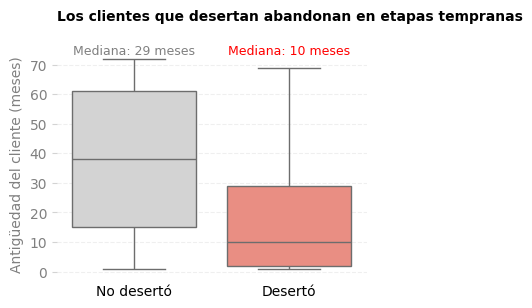

In [35]:
plt.figure(figsize=(4,3))

df['Desercion_label'] = df['Desercion'].map({0: 'No desertó', 1: 'Desertó'})

sns.boxplot(
    data=df,
    x='Desercion_label',
    y='Antigüedad_Meses',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    showfliers=False,
    legend=False
)

plt.xticks([0,1], ['No desertó', 'Desertó'])

plt.title(
    'Los clientes que desertan abandonan en etapas tempranas',
    fontsize=10,
    weight='bold',
    loc='left',
    pad=20
)

plt.text(
    0, df['Antigüedad_Meses'].max() * 1.02,
    'Mediana: 29 meses',
    ha='center',
    fontsize=9,
    color='gray'
)

plt.text(
    1, df['Antigüedad_Meses'].max() * 1.02,
    'Mediana: 10 meses',
    ha='center',
    fontsize=9,
    color='red'
)

plt.ylabel('Antigüedad del cliente (meses)', color='gray')
plt.yticks(color='gray')
plt.tick_params(axis='y', color='lightgray')
plt.tick_params(axis='x', color='lightgray', size=0)
plt.xlabel('')

plt.grid(axis='y', linestyle='--', alpha=0.2)
sns.despine(left=True, bottom=True)

plt.show()

#### Observaciones:
- La deserción ocurre principalmente en los primeros meses del cliente.
Los clientes que abandonan tienen una antigüedad media 44% menor y una mediana 65% menor que la base general, lo que evidencia una fuerte relación entre antigüedad y probabilidad de abandono.

In [36]:
corr, p_value = pointbiserialr(
    df['Desercion'],           # binaria (0/1)
    df['Antigüedad_Meses']     # numérica
)

corr, p_value

(np.float64(-0.354049358953251), np.float64(9.437650217577492e-207))

### Interpretación:
- Relación inversa entre las variables (−):
  - A mayor antigüedad del cliente, menor probabilidad de deserción.
- Magnitud (|r| = 0.35): Correlación negativa moderada.
- p-value ≈ 0 (9.43 × 10⁻²⁰⁷): La relación es estadísticamente significativa y no atribuible al azar.
- **p indica si existe relación (no es azar); r indica qué tan fuerte es y en qué sentido.**

**Conclusión:**
La antigüedad del cliente presenta una relación negativa moderada con la deserción, altamente significativa desde el punto de vista estadístico.

## ¿En qué tiempo de antiguedad la deserción es mayor?

In [37]:
labels = [
    '0–6 meses',
    '7–12 meses',
    '13–24 meses',
    '25–36 meses',
    '37–48 meses',
    '49–72 meses'
]

df['Antiguedad_bin'] = pd.cut(
    df['Antigüedad_Meses'],
    bins=[0, 6, 12, 24, 36, 48, 72],
    labels=labels,
    right=True,
    include_lowest=True
)

churn_rate = (
    df.groupby('Antiguedad_bin', observed=True)['Desercion']
      .mean()
      .reset_index()
)

churn_rate

,Antiguedad_bin,Desercion
0,0–6 meses,0.533333
1,7–12 meses,0.358865
2,13–24 meses,0.287109
3,25–36 meses,0.216346
4,37–48 meses,0.190289
5,49–72 meses,0.095132


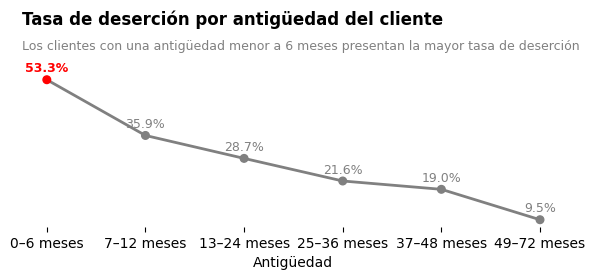

In [38]:
# Colores para cada punto
colorMarcador = [
    'red' if tasa == churn_rate['Desercion'].max() else 'gray'
    for tasa in churn_rate['Desercion']
]

fig, ax = plt.subplots(figsize=(7,2))
ax.set_frame_on(False) # Quita el marco del gráfico
ax.yaxis.set_visible(False)  # Quita las etiquetas del eje Y
ax.tick_params(axis='y', which='both', size=0) # Quita las marcas (ticks) del eje

# Línea
ax.plot(
    churn_rate['Antiguedad_bin'].astype(str),
    churn_rate['Desercion'],
    color='gray',
    linewidth=2,
    zorder=1
)

# Puntos
ax.scatter(
    churn_rate['Antiguedad_bin'].astype(str),
    churn_rate['Desercion'],
    color=colorMarcador,
    s=30,
    zorder=2
)

# Punto máximo
#max_row = churn_rate.loc[churn_rate['Desercion'].idxmax()]
#ax.annotate(
    #f'Máx: {max_row["Desercion"]:.1%}',
    #xy=(str(max_row['Antiguedad_bin']), max_row['Desercion']),
    #xytext=(0,10),
    #textcoords='offset points',
    #ha='center',
    #fontsize=9,
    #color='red'
#)

for _, row in churn_rate.iterrows():
    es_max = row['Desercion'] == churn_rate['Desercion'].max()

    ax.text(
        str(row['Antiguedad_bin']),
        row['Desercion'] + 0.015,
        f"{row['Desercion']:.1%}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='red' if es_max else 'gray',
        fontweight='bold' if es_max else 'normal',
        zorder=3
    )


ax.set_title(
    'Tasa de deserción por antigüedad del cliente',
    pad=35,
    fontsize=12,
    weight='bold',
    loc='left'
)

ax.text(
    0.0, 1.15,
    'Los clientes con una antigüedad menor a 6 meses presentan la mayor tasa de deserción',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

ax.set_ylabel('Tasa de deserción')
ax.set_xlabel('Antigüedad')
ax.grid(axis='y', linestyle='--', alpha=0.2)

# Guardar Gráfico como PNG
fig.savefig(carpeta_graficos+'/Antiguedad_Deserción.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

### ¿Los clientes mayores tienen una propensión mucho mayor al abandono?

In [39]:
tabla_propension = (
    df.groupby('Adulto_Mayor')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

tabla_propension.index = tabla_propension.index.map({
    0: 'No Adulto Mayor',
    1: 'Adulto Mayor'
})

tabla_propension.columns = ['No Desertó', 'Desertó']

tabla_propension

,No Desertó,Desertó
Adulto_Mayor,,
No Adulto Mayor,0.763497,0.236503
Adulto Mayor,0.583187,0.416813


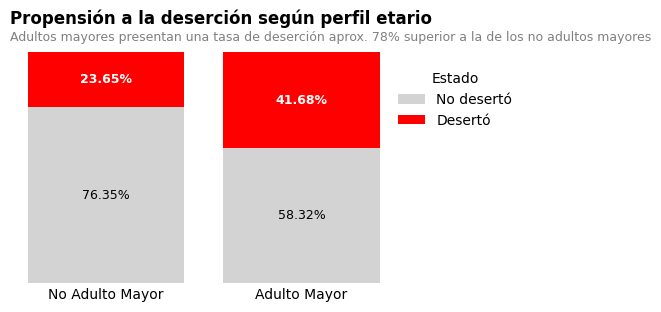

In [40]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = tabla_propension['No Desertó']
deserto = tabla_propension['Desertó']

# Barras apiladas
ax.bar(
    tabla_propension.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    tabla_propension.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje x

ax.set_title(
    'Propensión a la deserción según perfil etario',
    loc='left',
    weight='bold',
    pad=20
)

ax.text(
    0.0, 1.05,
    'Adultos mayores presentan una tasa de deserción aprox. 78% superior a la de los no adultos mayores',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(tabla_propension.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='white',
        weight='bold' # Ya estaba en negrita
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

plt.show()

### ¿El género es un factor de riesgo?.

In [41]:
genero_propension = (
    df.groupby('Genero')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

genero_propension.columns = ['No Desertó', 'Desertó']

(
    genero_propension
    .style
    .format('{:.2%}')
    .set_caption('Propensión a la deserción por género')

    # Heatmap suave SOLO en Desertó
    .background_gradient(
        subset=['Desertó'],
        cmap='Reds',
        low=0.2,
        high=0.6
    )

    # Estilo general de celdas
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11px'
    })

    # Estilos CSS
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('font-size', '13px'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('margin-bottom', '10px')
            ]
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#f7f7f7'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('font-size', '11px')
            ]
        },
        {
            'selector': 'td',
            'props': [
                ('border', '1px solid #eeeeee')
            ]
        }
    ])
)

,No Desertó,Desertó
Genero,,
Femenino,73.04%,26.96%
Masculino,73.80%,26.20%


#### Comparativa de Genero:
- La propensión a la deserción es prácticamente equivalente entre hombres y mujeres, por lo que el género no es un factor diferenciador relevante.

### ¿Los clientes con Pareja abandonan menos?

In [42]:
pareja_propension = (
    df.groupby('Pareja')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

pareja_propension.index = pareja_propension.index.map({
    0: 'Sin Pareja',
    1: 'Con Pareja'
})

pareja_propension.columns = ['No Desertó', 'Desertó']

pareja_propension

,No Desertó,Desertó
Pareja,,
Sin Pareja,0.670239,0.329761
Con Pareja,0.802829,0.197171


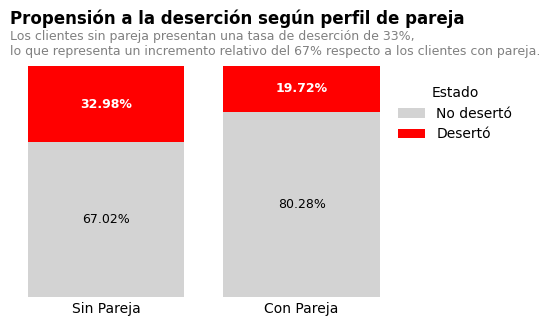

In [43]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = pareja_propension['No Desertó']
deserto = pareja_propension['Desertó']

# Barras apiladas
ax.bar(
    pareja_propension.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    pareja_propension.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje Y

ax.set_title(
    'Propensión a la deserción según perfil de pareja',
    loc='left',
    weight='bold',
    pad=30
)

ax.text(
    0.0, 1.05,
    'Los clientes sin pareja presentan una tasa de deserción de 33%,\nlo que representa un incremento relativo del 67% respecto a los clientes con pareja.',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(pareja_propension.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='white',
        weight='bold' # Ya estaba en negrita
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

plt.show()

¿Cuales son las tasas de deserción por tipo de contrato?

In [44]:
tipoContrato_propension = (
    df.groupby('Tipo_Contrato')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

#pareja_propension.index = pareja_propension.index.map({
    #0: 'Sin Pareja',
    #1: 'Con Pareja'
#})

tipoContrato_propension.columns = ['No Desertó', 'Desertó']

tipoContrato_propension

,No Desertó,Desertó
Tipo_Contrato,,
1 año,0.887228,0.112772
2 años,0.971513,0.028487
Mensual,0.572903,0.427097


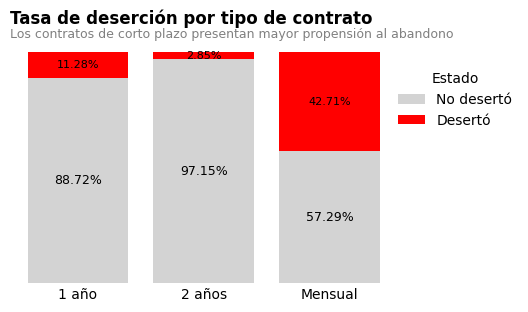

In [45]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = tipoContrato_propension['No Desertó']
deserto = tipoContrato_propension['Desertó']

# Barras apiladas
ax.bar(
    tipoContrato_propension.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    tipoContrato_propension.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje Y

ax.set_title(
    'Tasa de deserción por tipo de contrato',
    loc='left',
    weight='bold',
    pad=20
)

ax.text(
    0.0, 1.06,
    'Los contratos de corto plazo presentan mayor propensión al abandono',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(tipoContrato_propension.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=8,
        color='black',
        #weight='bold'
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

# Guardar Gráfico como PNG
fig.savefig(carpeta_graficos+'/TipoContrato_Deserción.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

### ¿Cual es la propensión a la deserción por método de pago?

In [46]:
metodoPago_propension = (
    df.groupby('Metodo_Pago')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

#pareja_propension.index = pareja_propension.index.map({
    #0: 'Sin Pareja',
    #1: 'Con Pareja'
#})

metodoPago_propension.columns = ['No Desertó', 'Desertó']

metodoPago_propension

,No Desertó,Desertó
Metodo_Pago,,
Cheque Electronico,0.547146,0.452854
Cheque por Correo,0.80798,0.19202
Tarjeta de Credito,0.847469,0.152531
Transferencia Bancaria,0.832685,0.167315


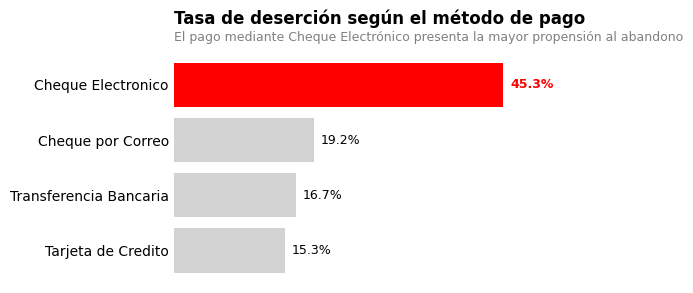

In [47]:
from matplotlib.colors import Normalize
fig, ax = plt.subplots(figsize=(5,3))

# Datos: SOLO desertores
deserto = metodoPago_propension['Desertó'].sort_values(ascending=True)

# Colores (resaltamos el máximo)
colors = [
    'red' if v == deserto.max() else 'lightgray'
    for v in deserto
]

# Barras horizontales
ax.barh(
    deserto.index,
    deserto.values,
    color=colors
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_xlim(0, deserto.max() + 0.08)

ax.xaxis.set_visible(False)
ax.tick_params(axis='x', which='both', size=0)
ax.tick_params(axis='y', which='both', size=0)

# Título
ax.set_title(
    'Tasa de deserción según el método de pago',
    loc='left',
    weight='bold',
    pad=20
)

# Subtítulo
ax.text(
    0.0, 1.05,
    'El pago mediante Cheque Electrónico presenta la mayor propensión al abandono',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

# Etiquetas de porcentaje
for i, v in enumerate(deserto.values):
    ax.text(
        v + 0.01,
        i,
        f'{v*100:.1f}%',
        va='center',
        fontsize=9,
        color='red' if v == deserto.max() else 'black',
        weight='bold' if v == deserto.max() else 'normal'
    )

# Guardar Gráfico como PNG
fig.savefig(carpeta_graficos+'/MétodoPago_Deserción.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

### ¿Que tipo de servicio de internet abandonan más?

In [48]:
servicioInternet_propension = (
    df.groupby('Servicio_Internet')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

#pareja_propension.index = pareja_propension.index.map({
    #0: 'Sin Pareja',
    #1: 'Con Pareja'
#})

servicioInternet_propension.columns = ['No Desertó', 'Desertó']
servicioInternet_propension

,No Desertó,Desertó
Servicio_Internet,,
DSL,0.810017,0.189983
Fiber optic,0.581072,0.418928
No,0.925658,0.074342


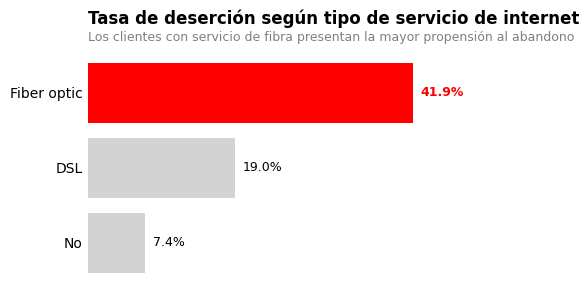

In [49]:
from matplotlib.colors import Normalize
fig, ax = plt.subplots(figsize=(5,3))

# Datos: SOLO desertores
deserto = servicioInternet_propension['Desertó'].sort_values(ascending=True)

# Colores (resaltamos el máximo)
colors = [
    'red' if v == deserto.max() else 'lightgray'
    for v in deserto
]

# Barras horizontales
ax.barh(
    deserto.index,
    deserto.values,
    color=colors
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_xlim(0, deserto.max() + 0.08)

ax.xaxis.set_visible(False)
ax.tick_params(axis='x', which='both', size=0)
ax.tick_params(axis='y', which='both', size=0)

# Título
ax.set_title(
    'Tasa de deserción según tipo de servicio de internet',
    loc='left',
    weight='bold',
    pad=20
)

# Subtítulo
ax.text(
    0.0, 1.05,
    'Los clientes con servicio de fibra presentan la mayor propensión al abandono',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

# Etiquetas de porcentaje
for i, v in enumerate(deserto.values):
    ax.text(
        v + 0.01,
        i,
        f'{v*100:.1f}%',
        va='center',
        fontsize=9,
        color='red' if v == deserto.max() else 'black',
        weight='bold' if v == deserto.max() else 'normal'
    )

# Guardar Gráfico como PNG
fig.savefig(carpeta_graficos+'/ServicioInternet_Deserción.png', transparent=False, dpi=300, bbox_inches='tight')

plt.show()

#### Observaciones de deserción por tipo de servicio de internet
- Los clientes que contratan servicio de fibra óptica presentan la mayor propensión a la deserción, con una tasa de abandono del 41.9%, más del doble que los clientes con DSL y casi seis veces superior a aquellos sin servicio de internet.

### ¿Los clientes con facturación electrónica presentan mayor o menor tasa de deserción que aquellos con facturación tradicional?

In [50]:
Facturacion_Sin_Papel = (
    df.groupby('Facturacion_Sin_Papel')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

Facturacion_Sin_Papel.index = Facturacion_Sin_Papel.index.map({
    0: 'Física',
    1: 'Electrónica'
})

Facturacion_Sin_Papel.columns = ['No Desertó', 'Desertó']

Facturacion_Sin_Papel

,No Desertó,Desertó
Facturacion_Sin_Papel,,
Física,0.836243,0.163757
Electrónica,0.664107,0.335893


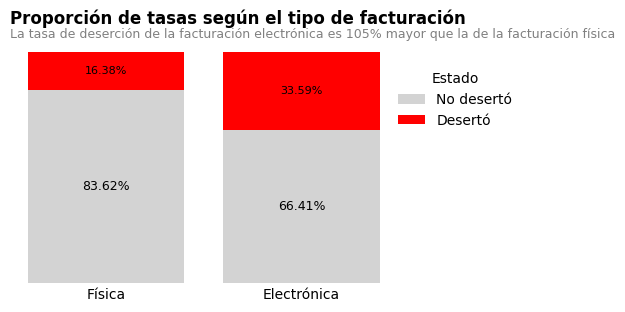

In [51]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = Facturacion_Sin_Papel['No Desertó']
deserto = Facturacion_Sin_Papel['Desertó']

# Barras apiladas
ax.bar(
    Facturacion_Sin_Papel.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    Facturacion_Sin_Papel.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje Y

ax.set_title(
    'Proporción de tasas según el tipo de facturación',
    loc='left',
    weight='bold',
    pad=20
)

ax.text(
    0.0, 1.06,
    'La tasa de deserción de la facturación electrónica es 105% mayor que la de la facturación física',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(Facturacion_Sin_Papel.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=8,
        color='black',
        #weight='bold'
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

plt.show()

### ¿La falta de servicios adicionales aumenta la deserción?

In [52]:
soporte_tecnico = (
    df[df['Soporte_Tecnico'] != 'No internet service']
    .groupby('Soporte_Tecnico')['Desercion']
    .value_counts(normalize=True)
    .unstack()
)

soporte_tecnico.index = soporte_tecnico.index.map({
    'No': 'No',
    'Yes': 'Si'
})


soporte_tecnico.columns = ['No Desertó', 'Desertó']
soporte_tecnico

,No Desertó,Desertó
Soporte_Tecnico,,
No,0.583525,0.416475
Si,0.848039,0.151961


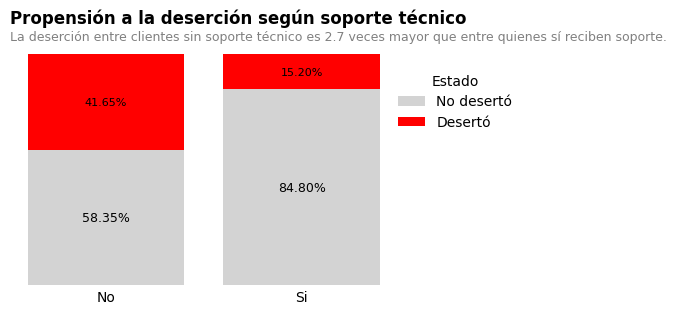

In [53]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = soporte_tecnico['No Desertó']
deserto = soporte_tecnico['Desertó']

# Barras apiladas
ax.bar(
    soporte_tecnico.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    soporte_tecnico.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje Y

ax.set_title(
    'Propensión a la deserción según soporte técnico',
    loc='left',
    weight='bold',
    pad=22
)

ax.text(
    0.0, 1.06,
    'La deserción entre clientes sin soporte técnico es 2.7 veces mayor que entre quienes sí reciben soporte.',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(soporte_tecnico.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=8,
        color='black',
        #weight='bold'
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

plt.show()

In [54]:
Seguridad_Online = (
    df[df['Seguridad_Online'] != 'No internet service']
      .groupby('Seguridad_Online')['Desercion']
      .value_counts(normalize=True)
      .unstack()
)

Seguridad_Online.index = Seguridad_Online.index.map({
    'No': 'No',
    'Yes': 'Si'
})

Seguridad_Online.columns = ['No Desertó', 'Desertó']

Seguridad_Online

,No Desertó,Desertó
Seguridad_Online,,
No,0.582213,0.417787
Si,0.853598,0.146402


### ¿Tener múltiples líneas aumenta la dependencia o la satisfacción?

In [55]:
Lineas_Multiples = (
    df[df['Lineas_Multiples'] != 'No phone service']
    .groupby('Lineas_Multiples')['Desercion']
    .value_counts(normalize=True)
    .unstack()
)

Lineas_Multiples.index = Lineas_Multiples.index.map({
    'No': 'No',
    'Yes': 'Si'
})


Lineas_Multiples.columns = ['No Desertó', 'Desertó']
Lineas_Multiples

,No Desertó,Desertó
Lineas_Multiples,,
No,0.749188,0.250812
Si,0.713515,0.286485


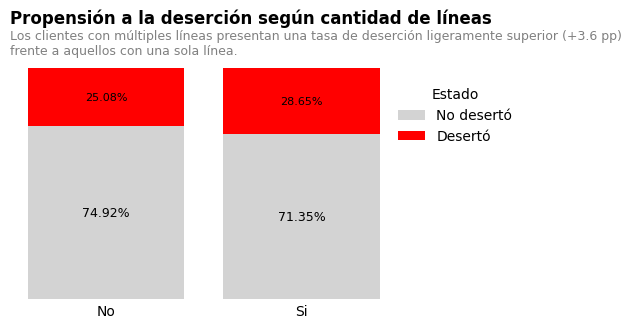

In [56]:
fig, ax = plt.subplots(figsize=(5,3))

# Valores
no_deserto = Lineas_Multiples['No Desertó']
deserto = Lineas_Multiples['Desertó']

# Barras apiladas
ax.bar(
    Lineas_Multiples.index,
    no_deserto,
    color='lightgray',
    label='No desertó'
)

ax.bar(
    Lineas_Multiples.index,
    deserto,
    bottom=no_deserto,
    color='red',
    label='Desertó'
)

# Estilo ejecutivo
ax.set_frame_on(False)
ax.set_ylim(0, 1)
#ax.set_yticks([0, 0.5, 1])
#ax.set_yticklabels(['0%', '50%', '100%'])
ax.yaxis.set_visible(False)                    # Oculta el eje y completo
ax.tick_params(axis='y', which='both', size=0) # Quitamos los ticks del eje Y
ax.tick_params(axis='x', which='both', size=0) # Quitamos los ticks del eje Y

ax.set_title(
    'Propensión a la deserción según cantidad de líneas',
    loc='left',
    weight='bold',
    pad=32
)

ax.text(
    0.0, 1.06,
    'Los clientes con múltiples líneas presentan una tasa de deserción ligeramente superior (+3.6 pp)\nfrente a aquellos con una sola línea.',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

for i, perfil in enumerate(Lineas_Multiples.index):
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'Desertó'
        no_deserto.iloc[i] + deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'Desertó'
        f'{deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=8,
        color='black',
        #weight='bold'
    )

    # 2. Etiquetas de "No Desertó"
    ax.text(
        i,
        # Posición Y: Mitad de la barra 'No Desertó'
        no_deserto.iloc[i] / 2,
        # Texto: Porcentaje de 'No Desertó'
        f'{no_deserto.iloc[i]*100:.2f}%',
        ha='center',
        va='center',
        fontsize=9,
        color='black', # Color negro para contraste
    )


ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.legend(title='Estado', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)

plt.show()

## Análisis Financiero y de Antigüedad

### Determinar si los clientes que abandonan son los que más o menos gastan mensualmente.

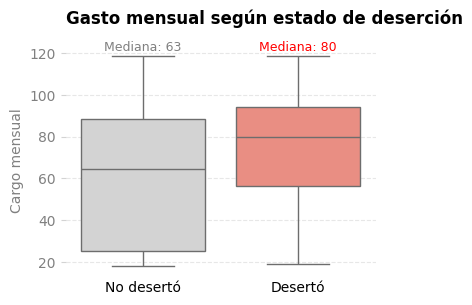

In [57]:
df['Desercion_label'] = df['Desercion'].map({
    0: 'No desertó',
    1: 'Desertó'
})

plt.figure(figsize=(4,3))


sns.boxplot(
    data=df,
    x='Desercion_label',
    y='Cargo_Mensual',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    showfliers=False,
    legend=False
)

plt.title(
    'Gasto mensual según estado de deserción',
    loc='left',
    weight='bold',
    pad=15
)

plt.text(
    0, df['Cargo_Mensual'].max() * 1.02,
    'Mediana: 63',
    ha='center',
    fontsize=9,
    color='gray'
)

plt.text(
    1, df['Cargo_Mensual'].max() * 1.02,
    'Mediana: 80',
    ha='center',
    fontsize=9,
    color='red'
)

plt.ylabel('Cargo mensual', color='gray')
plt.tick_params(axis='y', color='lightgray')
plt.yticks(color='gray')
plt.xlabel('')
plt.tick_params(axis='x', color='lightgray', size=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine(left=True, bottom=True)
plt.show()

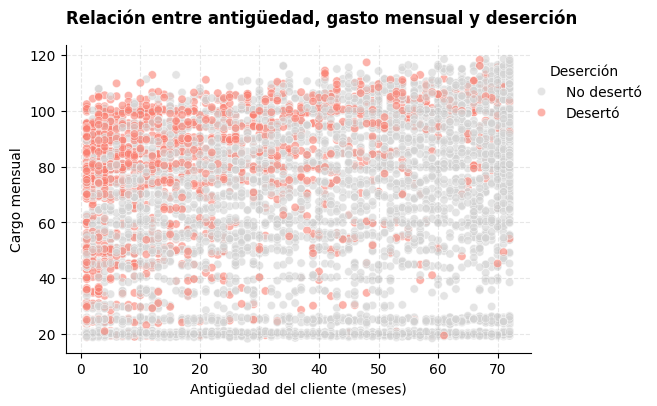

In [58]:
plt.figure(figsize=(6,4))

sns.scatterplot(
    data=df,
    x='Antigüedad_Meses',
    y='Cargo_Mensual',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    alpha=0.6
)

plt.title(
    'Relación entre antigüedad, gasto mensual y deserción',
    loc='left',
    weight='bold',
    pad=15
)

plt.xlabel('Antigüedad del cliente (meses)')
plt.ylabel('Cargo mensual')

plt.grid(True, linestyle='--', alpha=0.3)
sns.despine()
plt.legend(title='Deserción', frameon=False, bbox_to_anchor=(0.95, 1), loc='upper left', borderaxespad=1.)
plt.show()

#### Insight Cargo mensual vs Deserción:
- El churn afecta de forma desproporcionada a clientes de alto valor. Los desertores pagan, en promedio, cargos mensuales significativamente más altos, lo que representa un riesgo directo para los ingresos.

### ¿Los clientes que han gastado más en total tienen menor propensión a abandonar el servicio?

In [59]:
df[['Desercion','Cargo_Total']].corr()

,Desercion,Cargo_Total
Desercion,1.000000,-0.199484
Cargo_Total,-0.199484,1.000000


 Correlación Cargo Total vs Deserción
El menor gasto total de los clientes que desertan es una consecuencia de su corta permanencia y no un factor causal del abandono.

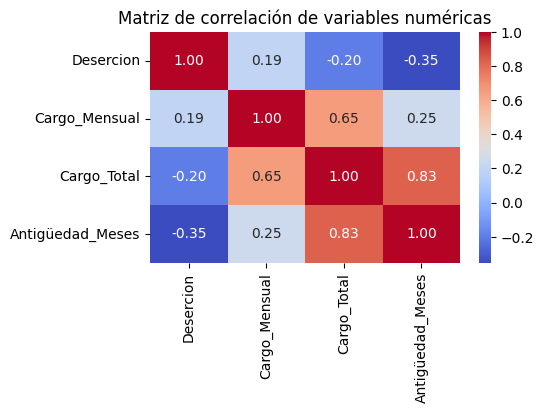

In [60]:
vars_numericas = df[[
    'Desercion',
    'Cargo_Mensual',
    'Cargo_Total',
    'Antigüedad_Meses'
]]

plt.figure(figsize=(5,3))
sns.heatmap(
    vars_numericas.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Matriz de correlación de variables numéricas')
plt.show()

#### Correlación de variables númericas
- La deserción presenta una relación negativa moderada con la antigüedad, lo que indica que el churn ocurre principalmente en los primeros meses.
Si bien el gasto total también se asocia negativamente con la deserción, esta relación está explicada en gran parte por la duración del cliente.
- En contraste, el cargo mensual muestra una relación positiva con el churn, sugiriendo que los clientes con planes más costosos presentan mayor riesgo de abandono.

### ¿Cómo varía la antigüedad promedio de los clientes según el tipo de contrato y su estado de deserción?

In [61]:
tenure_contrato_churn = (
    df
    .groupby(['Tipo_Contrato', 'Desercion'])['Antigüedad_Meses']
    .mean()
    .reset_index()
)

tenure_contrato_churn['Desercion_label'] = tenure_contrato_churn['Desercion'].map({
    0: 'No desertó',
    1: 'Desertó'
})

tenure_contrato_churn

,Tipo_Contrato,Desercion,Antigüedad_Meses,Desercion_label
0,1 año,0,41.705972,No desertó
1,1 año,1,44.963855,Desertó
2,2 años,0,56.948687,No desertó
3,2 años,1,61.270833,Desertó
4,Mensual,0,21.033333,No desertó
5,Mensual,1,14.016918,Desertó


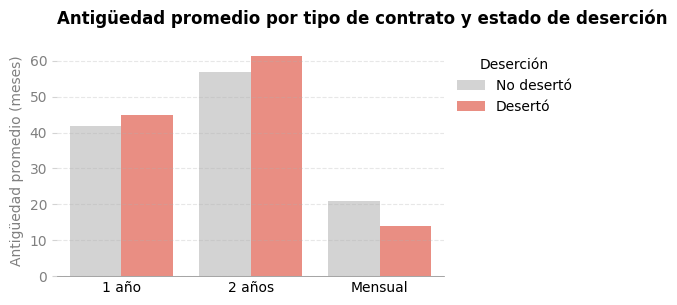

In [62]:
plt.figure(figsize=(5,3))

sns.barplot(
    data=tenure_contrato_churn,
    x='Tipo_Contrato',
    y='Antigüedad_Meses',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'}
)

plt.title(
    'Antigüedad promedio por tipo de contrato y estado de deserción',
    loc='left',
    weight='bold',
    pad=15
)

plt.ylabel('Antigüedad promedio (meses)', color='gray')
plt.xlabel('')

plt.legend(
    title='Deserción',
    frameon=False,
    bbox_to_anchor=(1,1),
    loc='upper left'
)

plt.tick_params(axis='x', size=0)
plt.tick_params(axis='y', color='lightgray')
plt.yticks(color='gray')

plt.grid(axis='y', linestyle='--', alpha=0.3)

# ---- Spines ----
ax = plt.gca()
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)

plt.show()

#### Insight Antiguedad promedios vs tipo de contrato
- Incluso en contratos de largo plazo, la deserción persiste y ocurre tras períodos significativos de permanencia, lo que sugiere que el contrato mitiga el abandono temprano, pero no garantiza la retención a largo plazo.

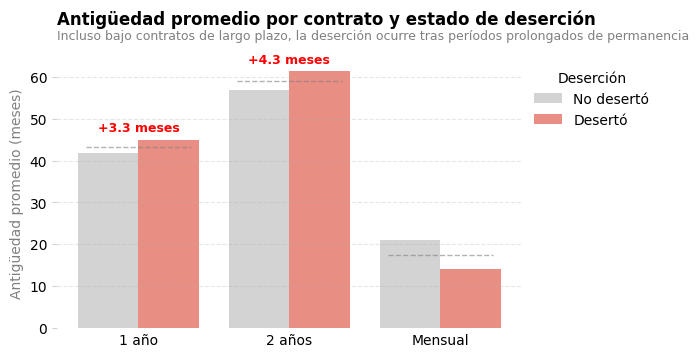

In [63]:
fig, ax = plt.subplots(figsize=(6,3.5))

sns.barplot(
    data=tenure_contrato_churn,
    x='Tipo_Contrato',
    y='Antigüedad_Meses',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    ax=ax
)

# --- Estilo base ---
ax.set_frame_on(False)
ax.tick_params(axis='x', size=0)
ax.tick_params(axis='y', color='lightgray')
ax.yaxis.label.set_color('gray')

ax.set_ylabel('Antigüedad promedio (meses)')
ax.set_xlabel('')

ax.set_title(
    'Antigüedad promedio por contrato y estado de deserción',
    loc='left',
    weight='bold',
    pad=25
)

ax.text(
    0.0, 1.07,
    'Incluso bajo contratos de largo plazo, la deserción ocurre tras períodos prolongados de permanencia',
    transform=ax.transAxes,
    ha='left',
    fontsize=9,
    color='gray'
)

# --- Líneas de referencia por contrato ---
for contrato in tenure_contrato_churn['Tipo_Contrato'].unique():
    media_contrato = (
        tenure_contrato_churn
        .loc[tenure_contrato_churn['Tipo_Contrato'] == contrato, 'Antigüedad_Meses']
        .mean()
    )

    xpos = list(tenure_contrato_churn['Tipo_Contrato'].unique()).index(contrato)

    ax.hlines(
        y=media_contrato,
        xmin=xpos - 0.35,
        xmax=xpos + 0.35,
        colors='gray',
        linestyles='dashed',
        linewidth=1,
        alpha=0.6
    )

# --- Anotación de brecha (solo donde aporta valor) ---
for contrato in ['1 año', '2 años']:
    subset = tenure_contrato_churn[
        tenure_contrato_churn['Tipo_Contrato'] == contrato
    ]

    no_deserto = subset.loc[subset['Desercion_label'] == 'No desertó', 'Antigüedad_Meses'].values[0]
    deserto = subset.loc[subset['Desercion_label'] == 'Desertó', 'Antigüedad_Meses'].values[0]

    diff = deserto - no_deserto
    xpos = list(tenure_contrato_churn['Tipo_Contrato'].unique()).index(contrato)

    ax.text(
        xpos,
        max(no_deserto, deserto) + 2,
        f'+{diff:.1f} meses',
        ha='center',
        fontsize=9,
        color='red',
        weight='bold'
    )

# --- Leyenda ---
ax.legend(
    title='Deserción',
    frameon=False,
    bbox_to_anchor=(1,1),
    loc='upper left'
)

ax.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine(left=True, bottom=True)

# ---- Spines ----
ax = plt.gca()
ax.spines['bottom'].set_color('gray')
ax.spines['bottom'].set_linewidth(0.5)

plt.show()

#### Insight antiguedad promedio vs contrato 2
- La mayor antigüedad de los clientes que desertan bajo contratos de 1 y 2 años sugiere que el riesgo de abandono aumenta cerca del vencimiento del compromiso contractual, lo que abre una ventana clara para acciones de retención anticipadas.

## ¿Cuándo ocurre la mayoría de las deserciones?

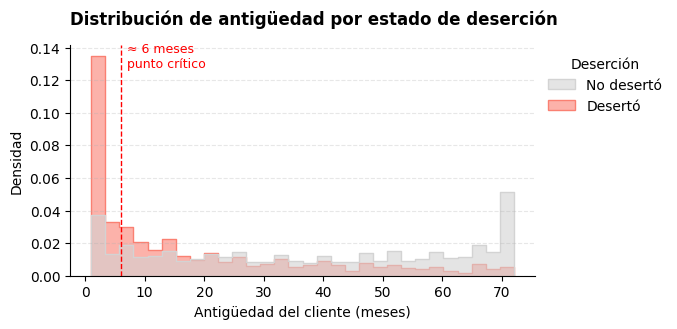

In [64]:
plt.figure(figsize=(6,3))

sns.histplot(
    data=df,
    x='Antigüedad_Meses',
    hue='Desercion_label',
    bins=30,
    stat='density',
    common_norm=False,
    element='step',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    alpha=0.6
)

# Línea de referencia (punto crítico)
plt.axvline(
    x=6,
    linestyle='--',
    color='red',
    linewidth=1
)

plt.text(
    7, plt.ylim()[1]*0.9,
    '≈ 6 meses\npunto crítico',
    color='red',
    fontsize=9,
    ha='left'
)

plt.title(
    'Distribución de antigüedad por estado de deserción',
    loc='left',
    weight='bold',
    pad=15
)

plt.xlabel('Antigüedad del cliente (meses)')
plt.ylabel('Densidad')

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
ax = plt.gca()
sns.move_legend(
    ax,
    "upper left",
    bbox_to_anchor=(1,1),
    title="Deserción",
    frameon=False
)

plt.show()

#### Insight densidad de deserción por antiguedad
- El histograma evidencia que la mayoría de las deserciones se concentran en los primeros 6 meses de antigüedad, identificando este periodo como el punto crítico de riesgo. A partir de este umbral, la frecuencia de abandono disminuye significativamente, lo que sugiere que los clientes que superan los 6 meses presentan una mayor probabilidad de permanencia.

## ¿Los precios de cada tipo de Internet tienen una distribución lógica y sin anomalías?

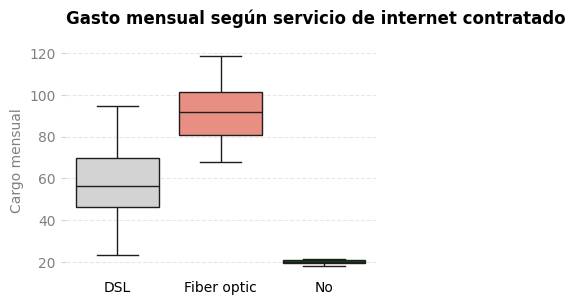

In [65]:
plt.figure(figsize=(4,3))
sns.boxplot(
    data=df,
    x='Servicio_Internet',
    y='Cargo_Mensual',
    hue='Servicio_Internet',
    palette={'DSL': 'lightgray', 'Fiber optic': 'salmon', 'No':'darkgreen'},
    showfliers=False,
    legend=False
)


plt.title(
    'Gasto mensual según servicio de internet contratado',
    loc='left',
    weight='bold',
    pad=15
)

plt.ylabel('Cargo mensual', color='gray')
plt.tick_params(axis='y', color='lightgray')
plt.yticks(color='gray')
plt.xlabel('')
plt.tick_params(axis='x', color='lightgray', size=0)
plt.grid(axis='y', linestyle='--', alpha=0.3)

sns.despine(left=True, bottom=True)
plt.show()

#### Insight Gastos mensuales según servicio de internet contratado
- El gráfico muestra una segmentación clara y consistente de los cargos mensuales según el tipo de servicio de internet. Fiber optic presenta los valores más elevados y mayor dispersión, seguido por DSL con cargos intermedios, mientras que los clientes sin servicio de internet exhiben cargos bajos y altamente concentrados. No se identifican anomalías ni valores atípicos relevantes, lo que sugiere una estructura de precios coherente y estable entre los distintos servicios.

## ¿La deserción en fibra ocurre temprano o incluso después de largos períodos de permanencia?

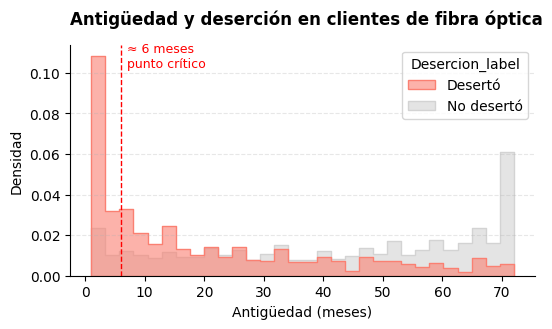

In [68]:
df_fiber = df[df['Servicio_Internet'] == 'Fiber optic']

plt.figure(figsize=(6,3))

sns.histplot(
    data=df_fiber,
    x='Antigüedad_Meses',
    hue='Desercion_label',
    bins=30,
    stat='density',
    common_norm=False,
    element='step',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    alpha=0.6
)

plt.axvline(6, linestyle='--', color='red', linewidth=1)
plt.text(7, plt.ylim()[1]*0.9, '≈ 6 meses\npunto crítico', color='red', fontsize=9)

plt.title(
    'Antigüedad y deserción en clientes de fibra óptica',
    loc='left', weight='bold', pad=15
)

plt.xlabel('Antigüedad (meses)')
plt.ylabel('Densidad')

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.show()

## Dentro de fibra óptica, ¿los que pagan más desertan más?

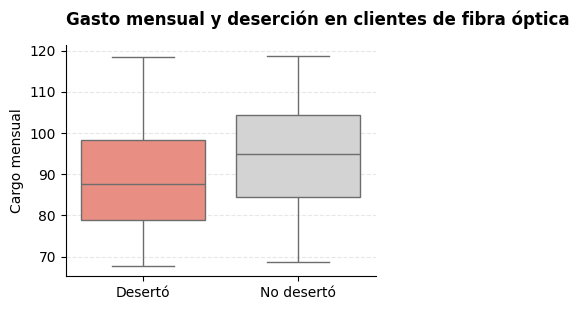

In [69]:
plt.figure(figsize=(4,3))

sns.boxplot(
    data=df_fiber,
    x='Desercion_label',
    y='Cargo_Mensual',
    hue='Desercion_label',
    palette={'No desertó': 'lightgray', 'Desertó': 'salmon'},
    showfliers=False,
    legend=False
)

plt.title(
    'Gasto mensual y deserción en clientes de fibra óptica',
    loc='left', weight='bold', pad=15
)

plt.ylabel('Cargo mensual')
plt.xlabel('')

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()
plt.show()


Insight clave combinado (Antiguedad + Cargos mensuales + Deserción):
Aunque la fibra óptica tiene los cargos mensuales más altos, los clientes que desertan no presentan un gasto superior al de quienes permanecen. La deserción se concentra principalmente en clientes de baja antigüedad, lo que sugiere que el abandono está más asociado a la experiencia temprana, expectativas del servicio o problemas de onboarding, y no al nivel de precio en sí mismo.

#📄Informe final


---

# Proyecto de Análisis de Datos

# Telecom X – Análisis de Deserción de Clientes (Churn)

**Rol:** Asistente de Análisis de Datos
**Dataset:** 7,032 registros de clientes
**Variables analizadas:** 23 características

---

# 1. Contexto del proyecto

En industrias de servicios como telecomunicaciones, la retención de clientes representa uno de los factores más importantes para la estabilidad financiera de la empresa. Adquirir nuevos clientes suele ser significativamente más costoso que mantener a los actuales, por lo que comprender las causas de la deserción se vuelve una prioridad estratégica.

El presente análisis explora el comportamiento de los clientes de **Telecom X**, con el objetivo de identificar patrones asociados al abandono del servicio (churn). Para ello se realiza un **análisis exploratorio de datos (EDA)** que permite examinar las características demográficas, contractuales y de uso del servicio.

El propósito final es generar conocimiento que permita diseñar estrategias de retención más efectivas y, en etapas posteriores, construir modelos predictivos que anticipen el riesgo de churn.

---

# 2. Objetivos del análisis

Este estudio tiene como meta principal **comprender los factores que influyen en la deserción de clientes** dentro de la base de datos analizada.

Los objetivos específicos son:

* Analizar la distribución y características de la base de clientes.
* Identificar variables que presentan una relación significativa con el churn.
* Detectar segmentos de clientes con mayor probabilidad de abandono.
* Generar insights que puedan ser utilizados en estrategias de retención.
* Definir variables relevantes para futuros modelos de predicción de churn.

---

# 3. Panorama general del dataset

La base de datos contiene información de **7,032 clientes**, incluyendo variables demográficas, detalles contractuales, servicios contratados y variables de facturación.

Entre las características más relevantes se encuentran:

* Información demográfica (género, edad, estado civil).
* Antigüedad del cliente en la empresa.
* Tipo de contrato.
* Servicios de telecomunicaciones contratados.
* Métodos de pago y facturación.
* Variables de facturación mensual y total.

El análisis inicial revela que **la tasa general de deserción es de aproximadamente 26.6%**, lo que indica que más de una cuarta parte de los clientes en la base han cancelado su servicio.

Desde una perspectiva de negocio, este nivel de churn representa una señal importante que justifica un análisis detallado de sus causas.

---

# 4. Perfil de los clientes

Antes de analizar la deserción, es importante comprender la estructura general de la base de clientes.

## 4.1 Características demográficas

La distribución de clientes por género es prácticamente equilibrada, con una proporción cercana al 50% entre hombres y mujeres. Esto sugiere que la base de clientes no presenta sesgos importantes en este aspecto.

En cuanto al grupo de **adultos mayores**, estos representan aproximadamente **16% del total de clientes**. Sin embargo, su comportamiento frente al churn es diferente al del resto de la población.

Por otra parte, el análisis de convivencia muestra que existe una ligera mayoría de clientes **sin pareja**, representando aproximadamente **52% de la base**.

Estas variables permiten establecer un primer panorama del tipo de clientes que componen la cartera de Telecom X.

---

## 4.2 Antigüedad del cliente

La antigüedad es una de las variables más importantes dentro del análisis de churn.

En la base analizada se observa que:

* La **mediana de antigüedad** es de aproximadamente **29 meses**.
* Existe una amplia dispersión en los datos.
* El primer cuartil se ubica alrededor de **10 meses**, mientras que el tercer cuartil se sitúa cerca de **55 meses**.

La distribución presenta una forma **bimodal**, lo que sugiere la coexistencia de dos grandes grupos dentro de la base: clientes relativamente nuevos y clientes con relaciones de largo plazo.

Este comportamiento puede tener implicaciones directas en la probabilidad de abandono.

---

## 4.3 Cargos mensuales

El análisis de los cargos mensuales revela una distribución heterogénea.

Se identifican tres segmentos principales dentro de la base:

* Clientes con cargos relativamente bajos.
* Clientes con cargos intermedios.
* Clientes con cargos mensuales elevados.

La distribución presenta una **asimetría hacia valores más altos**, lo que indica que existe un grupo relevante de clientes con servicios de mayor valor económico.

---

# 5. Factores asociados a la deserción

El análisis exploratorio permite identificar varias variables con una relación clara respecto al churn.

---

# 5.1 Antigüedad y abandono

La antigüedad del cliente muestra una relación inversa con la probabilidad de deserción.

En promedio:

* Los clientes que abandonan el servicio presentan una **antigüedad media de 18 meses**.
* En contraste, la base total de clientes tiene una antigüedad media cercana a **32 meses**.
* La **mediana de antigüedad de los desertores es de aproximadamente 10 meses**.

Este comportamiento evidencia una **correlación negativa moderada entre antigüedad y churn**, lo que indica que a medida que aumenta el tiempo de permanencia del cliente, disminuye su probabilidad de cancelar el servicio.

Al segmentar la antigüedad por periodos se observan diferencias importantes.

| Antigüedad     | Tasa de churn |
| -------------- | ------------- |
| 0 – 6 meses    | 53%           |
| 7 – 12 meses   | 36%           |
| 13 – 24 meses  | 29%           |
| 48 meses o más | < 10%         |

Esto sugiere que **los primeros meses de relación con el cliente constituyen la etapa más crítica para la retención**.

---

# 5.2 Variables sociodemográficas

El análisis de variables personales muestra resultados interesantes.

**Género**

No se observan diferencias relevantes en la tasa de deserción entre hombres y mujeres, lo que indica que esta variable no tiene un peso significativo en el comportamiento de churn.

**Adultos mayores**

Este grupo presenta una tasa de abandono cercana al **41.7%**, considerablemente superior al promedio general.

**Estado de pareja**

Los clientes que no tienen pareja muestran una tasa de churn cercana al **33%**, mientras que aquellos que viven con pareja presentan un nivel significativamente menor (**19.7%**).

Esto podría sugerir que los hogares con mayor estabilidad familiar tienden a mantener el servicio por más tiempo.

---

# 5.3 Tipo de contrato

El tipo de contrato emerge como uno de los factores más influyentes en la probabilidad de abandono.

| Tipo de contrato   | Tasa de churn |
| ------------------ | ------------- |
| Mensual            | 42.7%         |
| Contrato de 1 año  | 11.3%         |
| Contrato de 2 años | 2.8%          |

Los contratos mensuales presentan un nivel de churn considerablemente mayor, lo cual es consistente con la menor barrera de salida que ofrecen.

Por el contrario, los contratos de mayor duración funcionan como un mecanismo de retención natural al generar compromisos de permanencia.

Sin embargo, se observa que algunos clientes abandonan el servicio cerca del momento de renovación contractual, lo que abre oportunidades para estrategias de fidelización anticipada.

---

# 5.4 Método de pago

El método de pago también parece estar relacionado con la probabilidad de churn.

Los clientes que utilizan **cheque electrónico** presentan una tasa de abandono cercana al **45.3%**, significativamente superior a la de otros métodos.

En contraste, los métodos automáticos de pago, como tarjetas de crédito o transferencias bancarias, muestran menores niveles de deserción.

Esto podría reflejar diferencias en el nivel de compromiso del cliente o en la facilidad del proceso de pago.

---

# 5.5 Servicios contratados

## Servicio de internet

El tipo de conexión a internet presenta diferencias importantes en la tasa de abandono.

| Servicio                 | Tasa de churn |
| ------------------------ | ------------- |
| Fibra óptica             | 41.9%         |
| DSL                      | 19.0%         |
| Sin servicio de internet | 7.4%          |

El servicio de **fibra óptica** combina dos características relevantes: cargos mensuales más altos y una tasa de deserción elevada.

El análisis temporal sugiere que la mayoría de estas cancelaciones ocurre durante los primeros meses del servicio.

Esto apunta a posibles problemas en la experiencia inicial del cliente, como instalación, expectativas del servicio o soporte técnico.

---

## Servicios adicionales

El soporte técnico aparece como un factor importante de retención.

Los clientes que **no cuentan con soporte técnico** presentan una tasa de abandono **2.7 veces mayor** que aquellos que sí lo tienen.

Esto sugiere que los servicios complementarios pueden fortalecer la relación del cliente con la empresa y reducir la probabilidad de cancelación.

---

# 6. Impacto financiero del churn

El análisis de las variables de facturación permite comprender el impacto económico de la deserción.

**Cargo mensual**

* Clientes que abandonan: mediana cercana a **80**
* Clientes que permanecen: mediana cercana a **63**

Esto indica que el churn afecta en mayor medida a clientes con planes de mayor valor.

**Cargo total**

La relación observada entre cargo total y churn es negativa, lo cual se explica principalmente por la menor antigüedad de los clientes que abandonan.

---

# 7. Principales hallazgos del análisis

A partir del análisis exploratorio se identifican varios patrones relevantes:

1. La deserción se concentra principalmente en etapas tempranas de la relación con el cliente.
2. Los primeros seis meses representan el periodo más crítico para la retención.
3. Los contratos mensuales presentan el mayor riesgo de abandono.
4. El servicio de fibra óptica muestra una combinación de alto valor económico y alta tasa de churn.
5. Los servicios adicionales, particularmente el soporte técnico, contribuyen a mejorar la retención.
6. Los clientes con cargos mensuales más elevados presentan mayor probabilidad de abandono.

---

# 8. Recomendaciones estratégicas

## Acciones operativas inmediatas

* Implementar programas de **acompañamiento para nuevos clientes durante los primeros 90 días**.
* Fortalecer el **seguimiento a clientes que contratan fibra óptica**.
* Incentivar la migración hacia **contratos de mayor duración**.
* Promover el uso de **métodos de pago automáticos**.

---

## Estrategias de retención

Se recomienda implementar sistemas de monitoreo que identifiquen clientes con características de alto riesgo, tales como:

* Antigüedad inferior a 6 meses
* Cargos mensuales elevados
* Ausencia de soporte técnico
* Contratos mensuales

Asimismo, podrían desarrollarse campañas de renovación anticipada antes del vencimiento de contratos.

---

# 9. Conclusión

El análisis muestra que la deserción de clientes en Telecom X no ocurre de manera aleatoria. Por el contrario, está asociada a patrones identificables relacionados con la antigüedad del cliente, el tipo de contrato y los servicios contratados.

En particular, los **primeros meses de experiencia del cliente con la empresa** representan la etapa más determinante para su permanencia.

Desde una perspectiva estratégica, mejorar la experiencia inicial del cliente —especialmente en servicios de alto valor como la fibra óptica— representa una de las oportunidades más importantes para reducir el churn y fortalecer la estabilidad de ingresos de la empresa.

---
